# A Global Instrument
### *Modern Strain Gage Technology* — Companion Notebook

*Companion notebook to Chapter 6 — A Global Instrument.*

One physical principle — a bonded conductor whose resistance changes as it deforms — spread from two American laboratories in 1938 to every industrial nation on Earth within a generation. This notebook charts that spread.

The bonded resistance strain gage was invented in 1938, independently and almost simultaneously, by two researchers on opposite sides of the United States. Within two decades it had become the dominant tool for experimental stress analysis worldwide. The timeline below traces that arc — from a handful of university laboratories to a global measurement infrastructure that now spans automotive proving grounds, aerospace test facilities, civil monitoring projects, and consumer electronics.

The gaps between milestones are as instructive as the events themselves. Some transitions took decades (wire to foil); others happened within a few years (analog to digital). Taken together, they show a technology that advanced not in a straight line but in bursts — each burst triggered by an external force: war, aviation growth, the microprocessor, and now machine learning.

**This notebook demonstrates:**
1. A staggered-label timeline of global strain gage industry milestones (1938–2020)

In [1]:
# !pip install matplotlib
# (In Colab, uncomment the line above to install the single dependency.)

from pathlib import Path
import textwrap

import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Generated figures are written here; the book includes them from src/media/ch06/.
OUT_DIR = Path("../src/media/ch06")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Global Milestones Timeline

A technology's history is best read forward and backward simultaneously. Forward, to see the sequence of events; backward, to understand why each step was possible only when it was. The strain gage timeline has both qualities. The early milestones are separated by years — the time it took for a laboratory instrument to become a commercial product. The later milestones compress: digital electronics, personal computers, and wireless telemetry arrived within a generation and transformed every aspect of how strain data is collected and processed.

The twelve events plotted here are deliberately selective. Each represents a transition that changed not just the hardware but the practice — how engineers think about setting up a test, interpreting a result, or deploying a system. The staggered label layout keeps the labels readable even where events cluster; the alternating above/below pattern is a visual device, not a hierarchy.

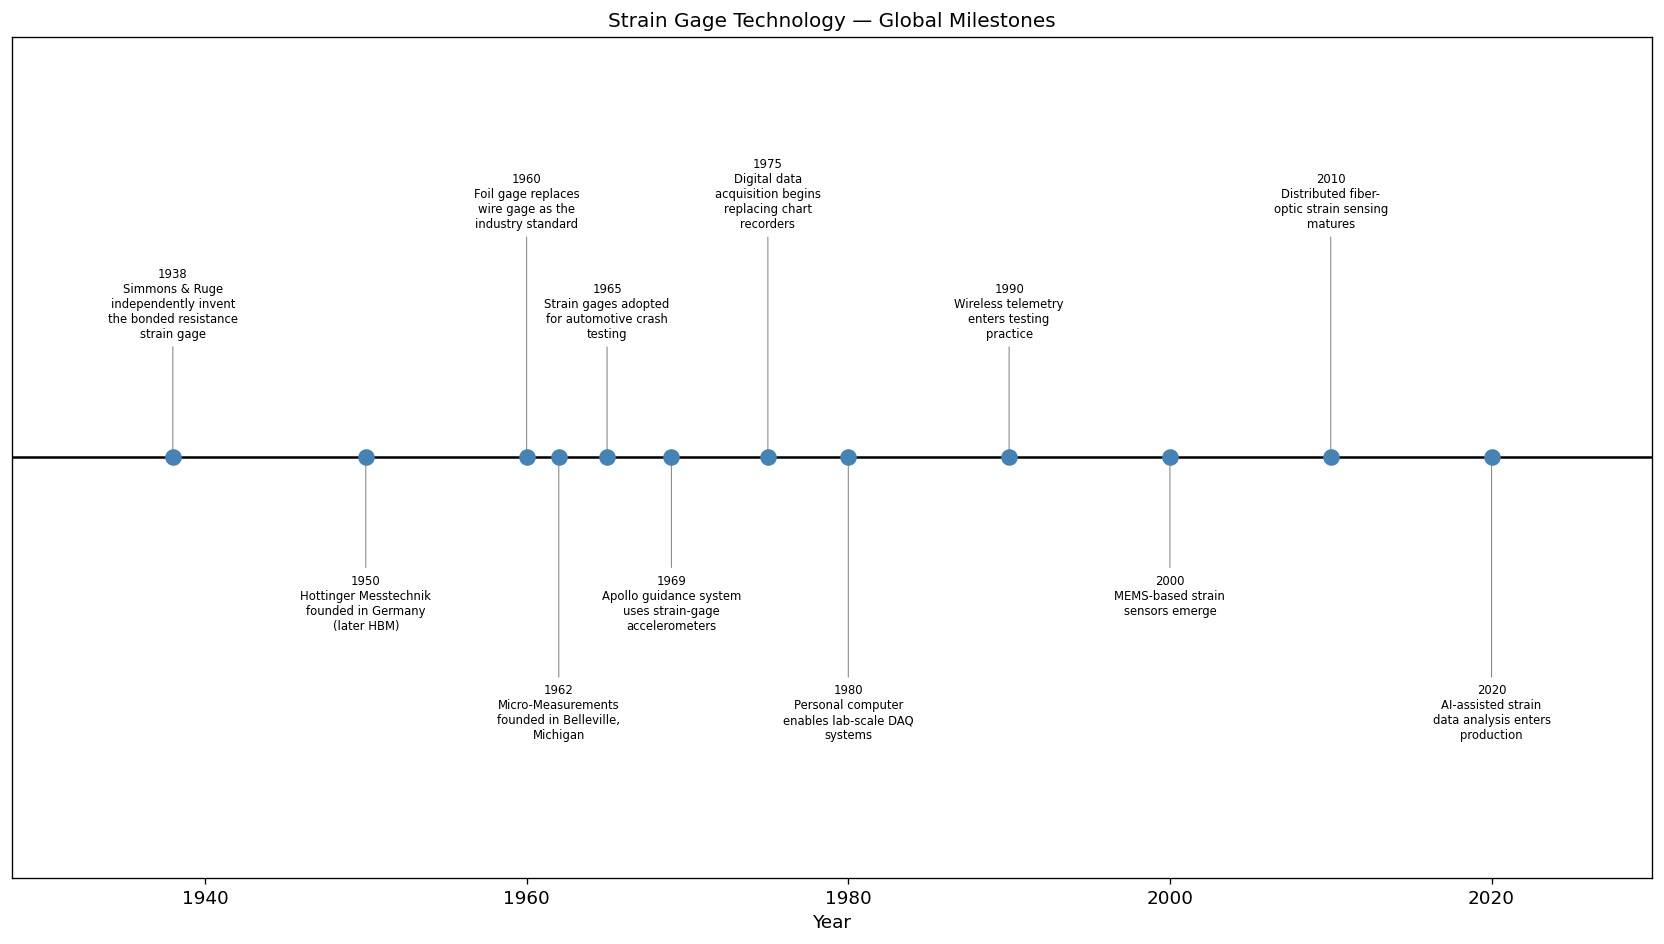

In [2]:
# Curated milestones in the global development of the bonded resistance strain gage.
# Dates and wording are kept consistent with the narrative of Chapter 6:
#   Hottinger Messtechnik was founded in 1950 (the HBM name came in 1963), and
#   Micro-Measurements was founded in Belleville, Michigan in the early 1960s.
MILESTONES = [
    (1938, "Simmons & Ruge independently invent the bonded resistance strain gage"),
    (1950, "Hottinger Messtechnik founded in Germany (later HBM)"),
    (1960, "Foil gage replaces wire gage as the industry standard"),
    (1962, "Micro-Measurements founded in Belleville, Michigan"),
    (1965, "Strain gages adopted for automotive crash testing"),
    (1969, "Apollo guidance system uses strain-gage accelerometers"),
    (1975, "Digital data acquisition begins replacing chart recorders"),
    (1980, "Personal computer enables lab-scale DAQ systems"),
    (1990, "Wireless telemetry enters testing practice"),
    (2000, "MEMS-based strain sensors emerge"),
    (2010, "Distributed fiber-optic strain sensing matures"),
    (2020, "AI-assisted strain data analysis enters production"),
]

# Layout constants.
LABEL_WRAP = 22          # characters per line inside each milestone label
MARKER_SIZE = 80         # scatter marker area for each event
AXIS_PAD_YEARS = 10      # blank margin on each side of the time axis
FIG_SIZE = (14, 8)
SAVE_DPI = 150
# Stagger levels cycle above/below and near/far, so that even closely spaced
# events (e.g. 1960 and 1962) land on opposite sides of the axis and never collide.
STAGGER_LEVELS = [0.32, -0.32, 0.62, -0.62]


def plot_milestone_timeline(milestones, out_path):
    """Draw a staggered-label timeline of strain-gage milestones and save it.

    Parameters
    ----------
    milestones : list of (int, str)
        (year, description) pairs in chronological order.
    out_path : pathlib.Path
        Destination PNG path. The book includes this exact file.

    Returns
    -------
    matplotlib.axes.Axes
        The axis the timeline was drawn on.
    """
    years = [year for year, _ in milestones]

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.scatter(years, [0] * len(years), s=MARKER_SIZE, zorder=5, color='steelblue')
    ax.axhline(0, color='black', lw=1.5)

    for i, (year, description) in enumerate(milestones):
        y_text = STAGGER_LEVELS[i % len(STAGGER_LEVELS)]
        above = y_text > 0
        label = f"{year}\n" + "\n".join(textwrap.wrap(description, width=LABEL_WRAP))
        ax.annotate(
            label,
            xy=(year, 0), xytext=(year, y_text),
            fontsize=7, ha='center', va='bottom' if above else 'top',
            multialignment='center',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.6),
        )

    ax.set_xlim(min(years) - AXIS_PAD_YEARS, max(years) + AXIS_PAD_YEARS)
    ax.set_ylim(-1.15, 1.15)
    ax.set_yticks([])
    ax.set_xlabel('Year')
    ax.set_title('Strain Gage Technology — Global Milestones')
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches='tight', dpi=SAVE_DPI)
    return ax


plot_milestone_timeline(MILESTONES, OUT_DIR / 'fig06_nb1_strain_gage_milestones.png')
plt.show()

---
## Where to take this next

This timeline is a scaffold, not a finished argument. A few concrete ways to extend it:

- **Rebalance the geography.** Chapter 6 is deliberately global, yet this list leans on American and European milestones. Add the founding of **Kyowa** (Japan, 1949) and its **K-1 gage** (1951), or **Tokyo Sokki / TML**, and color-code each event by region to watch invention spread across continents rather than radiate from one.
- **Overlay the driving forces.** The chapter argues that progress came in bursts, each triggered by an external pressure — war, the jet age, the microprocessor, and now machine learning. Shade the background into eras and label those forces, turning the timeline from a list into a causal story.
- **Make it data-driven and interactive.** Move the milestones into an external CSV (one row per event, with a source citation column) so the data is easy to audit and grow, then render it with an interactive library such as Plotly so a reader can hover on any point to see the evidence behind it.